# VGG16 + DenseNet121 Early Fusion — ROC, Parameters, and Branch-wise Grad-CAM

This modified notebook retains the original concatenation and attention early-fusion experiments and adds:

- ROC `y_true`/`y_prob` NPZ files for both models,
- a standard ROC NPZ alias for the automatically selected best model,
- model summaries and parameter counts,
- paper-ready metrics, confusion matrices, ROC curves, and training curves,
- Keras 3–safe branch-wise Grad-CAM using the internal VGG16 and DenseNet121 convolution layers,
- two Healthy and two Parkinson Grad-CAM examples saved directly to `/content/drive/MyDrive/ROC_DATA/`.

The Grad-CAM code uses the complete trained early-fusion prediction while calculating separate gradients for each CNN branch. It does not use the fusion, pooling, or dense layers as Grad-CAM feature maps.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import re
import gc
import glob
import json
import shutil
import zipfile
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
)

np.random.seed(42)
tf.random.set_seed(42)

# Custom Keras Layers for preprocessing
class VGG16PreprocessingLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return vgg16_preprocess(inputs)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super().get_config()
        return config

class DenseNetPreprocessingLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return densenet_preprocess(inputs)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super().get_config()
        return config


print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

# Configure GPU memory growth before creating a model.
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as error:
        print("GPU memory-growth warning:", error)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


In [3]:
# ================================
# PATHS
# ================================

ZIP_PATH = "/content/drive/MyDrive/Parkinson_zip_Dataset/Parkinson_dataset.zip"

UNZIP_DIR = "/content/drive/MyDrive/VGG16_DENSENET_"

SAVE_DIR = "/content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__"

# All paper-ready artifacts requested in this notebook are also saved
# directly in this root folder.
ROOT_OUTPUT_DIR = os.path.join(SAVE_DIR, "Paper_Ready_Artifacts")

MODEL_DIR = os.path.join(SAVE_DIR, "models")
HISTORY_DIR = os.path.join(SAVE_DIR, "history_files")
GRAPH_DIR = os.path.join(SAVE_DIR, "graphs")
CM_DIR = os.path.join(SAVE_DIR, "confusion_matrices")
REPORT_DIR = os.path.join(SAVE_DIR, "reports")
GRADCAM_DIR = os.path.join(SAVE_DIR, "gradcam_heatmaps")

for directory in [
    UNZIP_DIR,
    SAVE_DIR,
    MODEL_DIR,
    HISTORY_DIR,
    GRAPH_DIR,
    CM_DIR,
    REPORT_DIR,
    GRADCAM_DIR,
    ROOT_OUTPUT_DIR,
]:
    os.makedirs(directory, exist_ok=True)

print("ZIP_PATH:", ZIP_PATH)
print("UNZIP_DIR:", UNZIP_DIR)
print("SAVE_DIR:", SAVE_DIR)
print("ROOT_OUTPUT_DIR:", ROOT_OUTPUT_DIR)

ZIP_PATH: /content/drive/MyDrive/Parkinson_zip_Dataset/Parkinson_dataset.zip
UNZIP_DIR: /content/drive/MyDrive/VGG16_DENSENET_
SAVE_DIR: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__
ROOT_OUTPUT_DIR: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts


In [4]:
# ================================
# UNZIP DATASET
# ================================

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

expected_extracted_dir = os.path.join(UNZIP_DIR, "Parkinson_dataset")

# Avoid deleting and re-extracting a valid dataset every time the notebook runs.
existing_images = []
if os.path.isdir(expected_extracted_dir):
    for extension in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
        existing_images.extend(
            glob.glob(
                os.path.join(expected_extracted_dir, "**", extension),
                recursive=True,
            )
        )

if existing_images:
    print("Using existing extracted dataset:", expected_extracted_dir)
    print("Existing image count:", len(existing_images))
else:
    if os.path.isdir(expected_extracted_dir):
        print("Removing incomplete extracted directory:", expected_extracted_dir)
        shutil.rmtree(expected_extracted_dir)

    print(f"Unzipping dataset to {UNZIP_DIR}...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(UNZIP_DIR)

    print("Dataset unzipped to:", UNZIP_DIR)

if not os.path.isdir(expected_extracted_dir):
    raise FileNotFoundError(
        "The expected Parkinson_dataset folder was not found after extraction. "
        "Check the internal structure of the ZIP file."
    )

print("Dataset root:", expected_extracted_dir)

Using existing extracted dataset: /content/drive/MyDrive/VGG16_DENSENET_/Parkinson_dataset
Existing image count: 11120
Dataset root: /content/drive/MyDrive/VGG16_DENSENET_/Parkinson_dataset


In [5]:
# ================================
# FIND IMAGE FILES
# ================================

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]

all_images = []

for ext in image_extensions:
    all_images.extend(
        glob.glob(os.path.join(expected_extracted_dir, "**", ext), recursive=True)
    )

print("Total images found:", len(all_images))

if len(all_images) == 0:
    raise ValueError("No images found. Check dataset folder structure.")

for p in all_images[:10]:
    print(p)


# ================================
# CREATE DATAFRAME
# ================================

data = []

for img_path in all_images:
    lower_path = img_path.lower()

    if "healthy" in lower_path or "normal" in lower_path or "control" in lower_path:
        label = 0
        data.append([img_path, label])

    elif "parkinson" in lower_path or "pd" in lower_path:
        label = 1
        data.append([img_path, label])

df = pd.DataFrame(data, columns=["image_path", "label"])

print("Total labeled images:", len(df))
print(df.head())
print("\nClass counts:")
print(df["label"].value_counts())

if len(df) == 0:
    raise ValueError("No labeled images found. Folder names should contain healthy/control/normal or parkinson/pd.")

if df["label"].nunique() != 2:
    raise ValueError("Both classes not found. Need Healthy and Parkinson images.")

Total images found: 11120
/content/drive/MyDrive/VGG16_DENSENET_/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230127000630309_27_S1190701_I1660562.png
/content/drive/MyDrive/VGG16_DENSENET_/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230127000630510_34_S1190701_I1660562.png
/content/drive/MyDrive/VGG16_DENSENET_/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230127000640905_14_S1190701_I1660562.png
/content/drive/MyDrive/VGG16_DENSENET_/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230127000657892_154_S1190701_I1660562.png
/content/drive/MyDrive/VGG16_DENSENET_/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230127000706122_110_S1190701_I1660562.png
/content/drive/MyDrive/VGG16_DENSENET_/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_2

In [6]:
# ================================
# SPLIT DATASET
# ================================

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain counts:")
print(train_df["label"].value_counts())

print("\nValidation counts:")
print(val_df["label"].value_counts())

print("\nTest counts:")
print(test_df["label"].value_counts())

Train shape: (7784, 2)
Validation shape: (1668, 2)
Test shape: (1668, 2)

Train counts:
label
1    3892
0    3892
Name: count, dtype: int64

Validation counts:
label
0    834
1    834
Name: count, dtype: int64

Test counts:
label
0    834
1    834
Name: count, dtype: int64


In [7]:
# ================================
# IMAGE GENERATORS
# ================================

IMG_SIZE = 224

# Fusion model is heavy, so start with 8.
# If GPU memory is strong, you can try 16.
BATCH_SIZE = 8

EPOCHS = 35

train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 7784 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}


In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

# ================================
# MODEL A: VGG16 + DenseNet121 CONCATENATION FUSION
# ================================

def build_vgg16_densenet_concat_model(base_trainable=True):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")

    # Branch-specific preprocessing
    # Using custom layers instead of Lambda for better serialization
    vgg_input = VGG16PreprocessingLayer(name="vgg16_preprocessing")(inputs)
    dense_input = DenseNetPreprocessingLayer(name="densenet_preprocessing")(inputs)

    # VGG16 backbone
    raw_vgg = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    vgg_backbone = keras.Model(
        inputs=raw_vgg.input,
        outputs=raw_vgg.output,
        name="vgg16_backbone"
    )

    vgg_backbone.trainable = base_trainable

    # DenseNet121 backbone
    raw_dense = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    densenet_backbone = keras.Model(
        inputs=raw_dense.input,
        outputs=raw_dense.output,
        name="densenet121_backbone"
    )

    densenet_backbone.trainable = base_trainable

    # Feature maps
    vgg_features = vgg_backbone(vgg_input)
    dense_features = densenet_backbone(dense_input)

    # Convert feature maps to vectors
    vgg_vector = layers.GlobalAveragePooling2D(name="vgg16_gap")(vgg_features)
    dense_vector = layers.GlobalAveragePooling2D(name="densenet_gap")(dense_features)

    # Early fusion by concatenation
    fused = layers.Concatenate(name="early_fusion_concatenation")(
        [vgg_vector, dense_vector]
    )

    x = layers.Dense(512, activation="relu")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="VGG16_DenseNet121_Early_Fusion_Concatenation"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

# ================================
# MODEL B: VGG16 + DenseNet121 ATTENTION FUSION
# ================================

def build_vgg16_densenet_attention_model(base_trainable=True):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="mri_input")

    # Branch-specific preprocessing
    # Using custom layers instead of Lambda for better serialization
    vgg_input = VGG16PreprocessingLayer(name="vgg16_preprocessing")(inputs)
    dense_input = DenseNetPreprocessingLayer(name="densenet_preprocessing")(inputs)

    # VGG16 backbone
    raw_vgg = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    vgg_backbone = keras.Model(
        inputs=raw_vgg.input,
        outputs=raw_vgg.output,
        name="vgg16_backbone"
    )

    vgg_backbone.trainable = base_trainable

    # DenseNet121 backbone
    raw_dense = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    densenet_backbone = keras.Model(
        inputs=raw_dense.input,
        outputs=raw_dense.output,
        name="densenet121_backbone"
    )

    densenet_backbone.trainable = base_trainable

    # Feature maps
    vgg_features = vgg_backbone(vgg_input)
    dense_features = densenet_backbone(dense_input)

    # Convert feature maps to vectors
    vgg_vector = layers.GlobalAveragePooling2D(name="vgg16_gap")(vgg_features)
    dense_vector = layers.GlobalAveragePooling2D(name="densenet_gap")(dense_features)

    # Project both features to same size
    vgg_projected = layers.Dense(256, activation="relu", name="vgg16_projected")(vgg_vector)
    dense_projected = layers.Dense(256, activation="relu", name="densenet_projected")(dense_vector)

    # Create attention weights for both branches
    combined_features = layers.Concatenate(name="attention_input")(
        [vgg_projected, dense_projected]
    )

    attention_weights = layers.Dense(
        2,
        activation="softmax",
        name="branch_attention_weights"
    )(combined_features)

    # Apply attention weights
    weighted_vgg = layers.Lambda(
        lambda x: x[0] * x[1][:, 0:1],
        name="weighted_vgg16_features"
    )([vgg_projected, attention_weights])

    weighted_dense = layers.Lambda(
        lambda x: x[0] * x[1][:, 1:2],
        name="weighted_densenet_features"
    )([dense_projected, attention_weights])

    # Early fusion by attention
    fused = layers.Add(name="early_fusion_attention")(
        [weighted_vgg, weighted_dense]
    )

    x = layers.Dense(256, activation="relu")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="VGG16_DenseNet121_Early_Fusion_Attention"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [10]:
# ================================
# TRAINING-CURVE FUNCTION
# ================================

def plot_training_history(history, model_name, file_prefix):
    hist = history.history

    required_keys = ["accuracy", "val_accuracy", "loss", "val_loss"]
    missing_keys = [key for key in required_keys if key not in hist]
    if missing_keys:
        raise KeyError(f"Missing training-history keys: {missing_keys}")

    epochs = np.arange(1, len(hist["accuracy"]) + 1)

    plot_specs = [
        (
            "accuracy",
            "val_accuracy",
            "Accuracy",
            f"{model_name} — Training vs Validation Accuracy",
            f"{file_prefix}_accuracy.png",
        ),
        (
            "loss",
            "val_loss",
            "Loss",
            f"{model_name} — Training vs Validation Loss",
            f"{file_prefix}_loss.png",
        ),
    ]

    if "auc" in hist and "val_auc" in hist:
        plot_specs.append(
            (
                "auc",
                "val_auc",
                "AUC",
                f"{model_name} — Training vs Validation AUC",
                f"{file_prefix}_auc.png",
            )
        )

    for train_key, val_key, ylabel, title, filename in plot_specs:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist[train_key], label=f"Training {ylabel}")
        plt.plot(epochs, hist[val_key], label=f"Validation {ylabel}")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()

        root_path = os.path.join(ROOT_OUTPUT_DIR, filename)
        plt.savefig(root_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", root_path)

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ================================
# EVALUATION + ROC NPZ + PAPER ARTIFACTS
# ================================

def _save_model_metadata(model, model_name, file_prefix):
    summary_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_model_summary.txt",
    )

    with open(summary_path, "w", encoding="utf-8") as file:
        model.summary(print_fn=lambda line: file.write(line + "\n"))

    total_params = int(model.count_params())
    trainable_params = int(
        sum(
            tf.keras.backend.count_params(weight)
            for weight in model.trainable_weights
        )
    )
    non_trainable_params = int(
        sum(
            tf.keras.backend.count_params(weight)
            for weight in model.non_trainable_weights
        )
    )

    parameter_df = pd.DataFrame(
        [
            {
                "Model": model_name,
                "Backbone 1": "VGG16",
                "Backbone 2": "DenseNet121",
                "Total Parameters": total_params,
                "Trainable Parameters": trainable_params,
                "Non-Trainable Parameters": non_trainable_params,
            }
        ]
    )

    parameter_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_parameters.csv",
    )
    parameter_df.to_csv(parameter_path, index=False)

    print("Saved:", summary_path)
    print("Saved:", parameter_path)

    return {
        "summary_path": summary_path,
        "parameter_path": parameter_path,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
    }


def evaluate_model(model, test_gen, model_name, file_prefix):
    test_gen.reset()

    y_prob = np.asarray(
        model.predict(test_gen, verbose=1)
    ).reshape(-1).astype(np.float32)

    y_true = np.asarray(test_gen.classes).reshape(-1).astype(np.int32)

    if len(y_true) != len(y_prob):
        raise ValueError(
            f"Prediction/label length mismatch: {len(y_prob)} vs {len(y_true)}"
        )

    if not np.isfinite(y_prob).all():
        raise ValueError("y_prob contains NaN or infinite values.")

    if np.min(y_prob) < 0.0 or np.max(y_prob) > 1.0:
        raise ValueError(
            "The model output is not in the probability range [0, 1]."
        )

    y_pred = (y_prob >= 0.5).astype(np.int32)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    print("\n==============================")
    print(model_name)
    print("==============================")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC AUC:", auc)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Healthy", "Parkinson"],
        digits=4,
        zero_division=0,
    )
    print("\nClassification Report:")
    print(report)

    # Save the exact ROC arrays needed for the combined ROC graph.
    roc_npz_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_roc_data.npz",
    )
    np.savez(
        roc_npz_path,
        y_true=y_true,
        y_prob=y_prob,
    )

    # Reload and verify the saved NPZ immediately.
    verification = np.load(roc_npz_path)
    print("ROC NPZ saved:", roc_npz_path)
    print("NPZ keys:", verification.files)
    print("y_true shape:", verification["y_true"].shape)
    print("y_prob shape:", verification["y_prob"].shape)
    print("y_true values:", np.unique(verification["y_true"]))
    print("y_prob range:", float(y_prob.min()), "to", float(y_prob.max()))

    metrics_df = pd.DataFrame(
        [
            {
                "Model": model_name,
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1 Score": f1,
                "ROC AUC": auc,
                "Threshold": 0.5,
                "Test Samples": len(y_true),
            }
        ]
    )
    metrics_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_metrics.csv",
    )
    metrics_df.to_csv(metrics_path, index=False)

    report_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_classification_report.txt",
    )
    with open(report_path, "w", encoding="utf-8") as file:
        file.write(f"Model: {model_name}\n")
        file.write(f"Accuracy: {accuracy:.8f}\n")
        file.write(f"Precision: {precision:.8f}\n")
        file.write(f"Recall: {recall:.8f}\n")
        file.write(f"F1 Score: {f1:.8f}\n")
        file.write(f"ROC AUC: {auc:.8f}\n\n")
        file.write(report)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, axis = plt.subplots(figsize=(6, 6))
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy", "Parkinson"],
    )
    display.plot(ax=axis, cmap="Blues", values_format="d", colorbar=False)
    axis.set_title(f"{model_name} — Confusion Matrix")
    fig.tight_layout()
    cm_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_confusion_matrix.png",
    )
    fig.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} — ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    roc_curve_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_roc_curve.png",
    )
    plt.savefig(roc_curve_path, dpi=300, bbox_inches="tight")
    plt.show()

    filepaths = list(getattr(test_gen, "filepaths", []))
    if len(filepaths) != len(y_true):
        filepaths = [""] * len(y_true)

    prediction_df = pd.DataFrame(
        {
            "image_path": filepaths,
            "true_label": y_true,
            "true_class": np.where(y_true == 1, "Parkinson", "Healthy"),
            "parkinson_probability": y_prob,
            "predicted_label": y_pred,
            "predicted_class": np.where(y_pred == 1, "Parkinson", "Healthy"),
            "correct": y_true == y_pred,
        }
    )
    predictions_path = os.path.join(
        ROOT_OUTPUT_DIR,
        f"{file_prefix}_test_predictions.csv",
    )
    prediction_df.to_csv(predictions_path, index=False)

    metadata = _save_model_metadata(model, model_name, file_prefix)

    print("Saved:", metrics_path)
    print("Saved:", report_path)
    print("Saved:", cm_path)
    print("Saved:", roc_curve_path)
    print("Saved:", predictions_path)

    return {
        "model_name": model_name,
        "file_prefix": file_prefix,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "roc_auc": float(auc),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "roc_npz_path": roc_npz_path,
        "metrics_path": metrics_path,
        "report_path": report_path,
        "cm_path": cm_path,
        "roc_curve_path": roc_curve_path,
        "predictions_path": predictions_path,
        **metadata,
    }

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_DenseNet121_Early_Fusion_Concatenation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (VGG16Preprocessin… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_preproces… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (DenseNetPreproces… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121_backbo… │ (None, 7, 7,      │  7,037,504 │ densenet_preproc… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_gap        │ (None, 1024)      │          0 │ densenet121_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_conca… │ (None, 1536)      │          0 │ vgg16_gap[0][0],  │
│ (Concatenate)       │                   │            │ densenet_gap[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    786,944 │ early_fusion_con… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,707,073 (86.62 MB)

 Trainable params: 22,621,633 (86.29 MB)

 Non-trainable params: 85,440 (333.75 KB)

Epoch 1/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5153 - auc: 0.5260 - loss: 0.9263
Epoch 1: val_auc improved from None to 0.65778, saving model to /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/models/VGG16_DenseNet121_Early_Fusion_Concatenation_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/models/VGG16_DenseNet121_Early_Fusion_Concatenation_best.keras
973/973 ━━━━━━━━━━━━━━━━━━━━ 2529s 2s/step - accuracy: 0.5224 - auc: 0.5327 - loss: 0.9168 - val_accuracy: 0.5108 - val_auc: 0.6578 - val_loss: 0.8292 - learning_rate: 1.0000e-05
Epoch 2/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5302 - auc: 0.5511 - loss: 0.8859
Epoch 2: val_auc did not improve from 0.65778
973/973 ━━━━━━━━━━━━━━━━━━━━ 110s 113ms/step - accuracy: 0.5425 - auc: 0.5679 - loss: 0.8715 - val_accuracy: 0.5522 - val_auc: 0.6133 - val_loss: 1.5600 - learning_rate: 1.0000e-05
Epoch 3/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accura

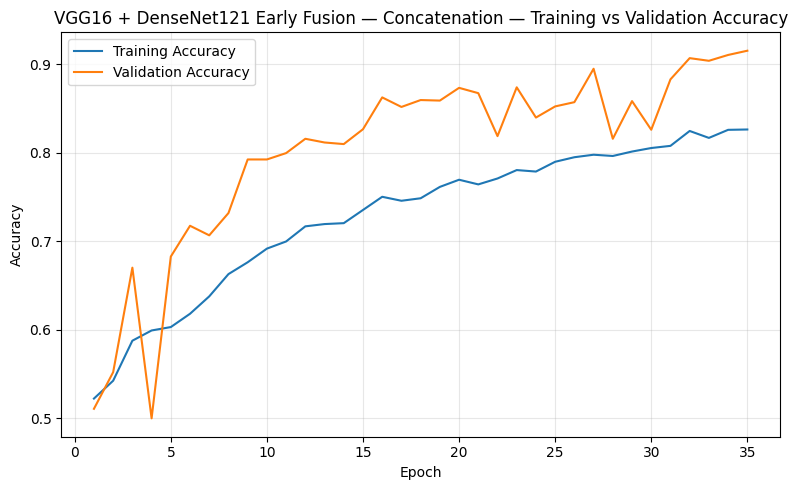

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_accuracy.png


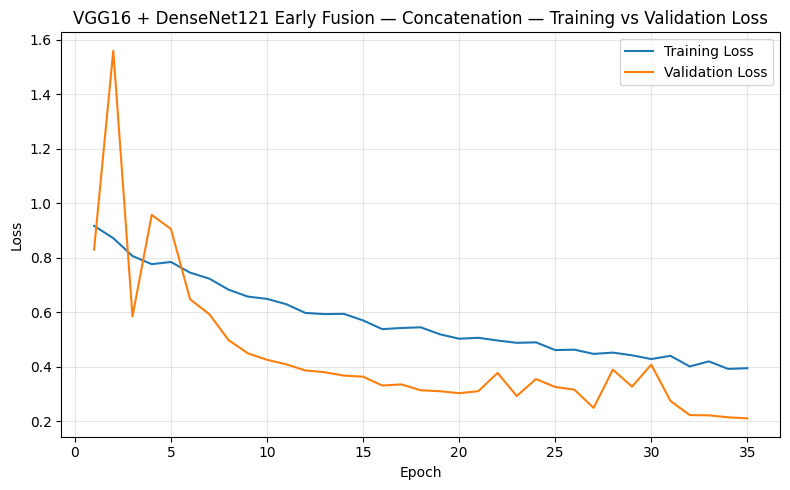

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_loss.png


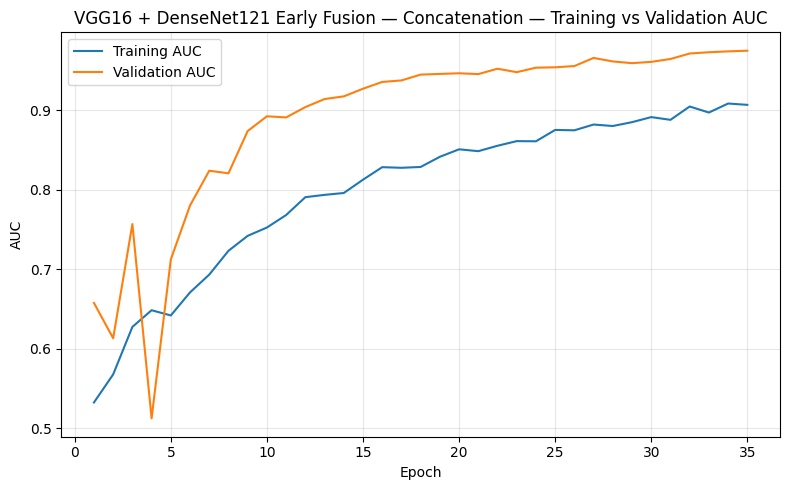

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_auc.png
209/209 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step

VGG16 + DenseNet121 Early Fusion — Concatenation
Accuracy: 0.907673860911271
Precision: 0.8752759381898455
Recall: 0.9508393285371702
F1 Score: 0.9114942528735632
ROC AUC: 0.9702310094370546

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9462    0.8645    0.9035       834
   Parkinson     0.8753    0.9508    0.9115       834

    accuracy                         0.9077      1668
   macro avg     0.9107    0.9077    0.9075      1668
weighted avg     0.9107    0.9077    0.9075      1668

ROC NPZ saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_roc_data.npz
NPZ keys: ['y_true', 'y_prob']
y_true shape: (1668,)
y_prob shape: (1668,)
y_true values: [0 1]
y_prob range: 2.6819338017958216e-05 to 0.99980151653289

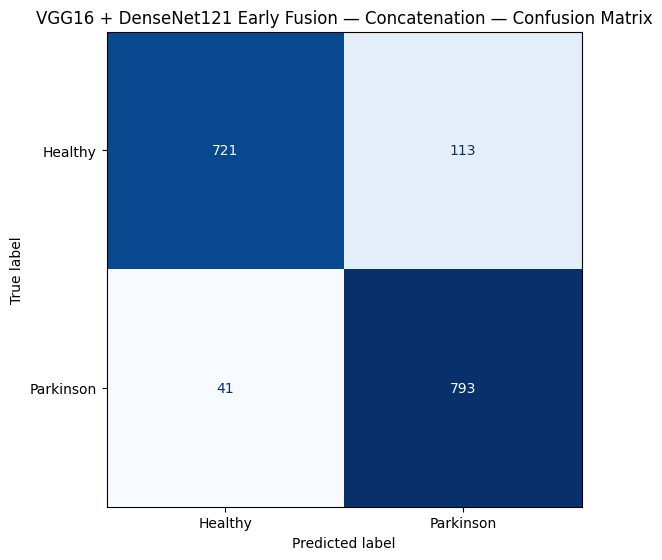

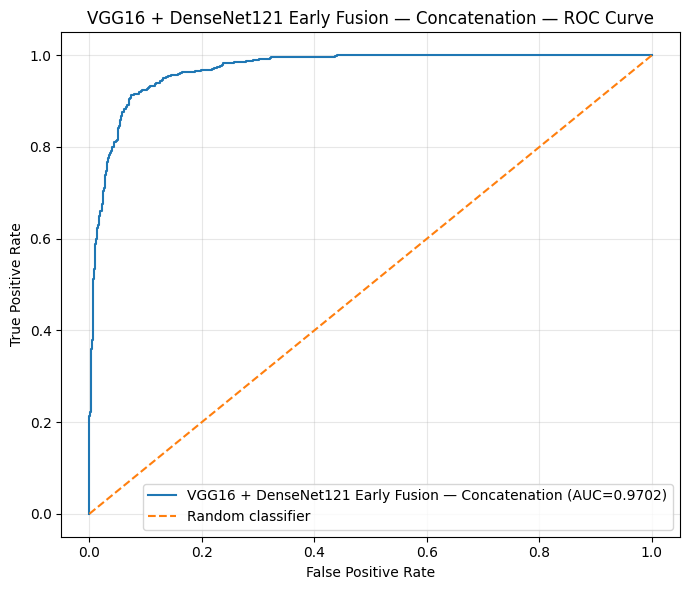

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_model_summary.txt
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_parameters.csv
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_metrics.csv
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_classification_report.txt
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_confusion_matrix.png
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_roc_curve.png
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_test_predictions.csv
Concatenation model released from memory.


In [12]:
# ================================
# TRAIN MODEL A: CONCATENATION FUSION
# ================================

model_name_concat = "VGG16 + DenseNet121 Early Fusion — Concatenation"
concat_prefix = "vgg16_densenet_concat_early_fusion"
concat_checkpoint_path = os.path.join(
    MODEL_DIR,
    "VGG16_DenseNet121_Early_Fusion_Concatenation_best.keras",
)

concat_model = build_vgg16_densenet_concat_model(base_trainable=True)
concat_model.summary()

callbacks_concat = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=concat_checkpoint_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    CSVLogger(
        filename=os.path.join(
            HISTORY_DIR,
            f"{concat_prefix}_training_log.csv",
        )
    ),
]

history_concat = concat_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_concat,
)

concat_final_path = os.path.join(
    MODEL_DIR,
    "VGG16_DenseNet121_Early_Fusion_Concatenation_final.keras",
)
concat_model.save(concat_final_path)
print("Final model saved:", concat_final_path)

history_concat_path = os.path.join(
    HISTORY_DIR,
    f"{concat_prefix}_history.json",
)
with open(history_concat_path, "w", encoding="utf-8") as file:
    json.dump(history_concat.history, file)
print("History saved:", history_concat_path)

plot_training_history(
    history_concat,
    model_name_concat,
    concat_prefix,
)

results_concat = evaluate_model(
    concat_model,
    test_gen,
    model_name_concat,
    concat_prefix,
)
results_concat["checkpoint_path"] = concat_checkpoint_path
results_concat["final_model_path"] = concat_final_path

# Release the first large fusion model before building the second one.
del concat_model
del history_concat
gc.collect()
tf.keras.backend.clear_session()
print("Concatenation model released from memory.")

Model: "VGG16_DenseNet121_Early_Fusion_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (VGG16Preprocessin… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_preproces… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (DenseNetPreproces… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121_backbo… │ (None, 7, 7,      │  7,037,504 │ densenet_preproc… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_gap        │ (None, 1024)      │          0 │ densenet121_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_projected     │ (None, 256)       │    131,328 │ vgg16_gap[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_projected  │ (None, 256)       │    262,400 │ densenet_gap[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_input     │ (None, 512)       │          0 │ vgg16_projected[… │
│ (Concatenate)       │                   │            │ densenet_project… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_attention_w… │ (None, 2)         │      1,026 │ attention_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_vgg16_fea… │ (None, 256)       │          0 │ vgg16_projected[… │
│ (Lambda)            │                   │            │ branch_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_densenet_… │ (None, 256)       │          0 │ densenet_project… │
│ (Lambda)            │                   │            │ branch_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_atten… │ (None, 256)       │          0 │ weighted_vgg16_f… │
│ (Add)               │                   │            │ weighted_densene… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ early_fusion_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 22,247,299 (84.87 MB)

 Trainable params: 22,162,883 (84.54 MB)

 Non-trainable params: 84,416 (329.75 KB)

Epoch 1/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5533 - auc: 0.5768 - loss: 0.8457
Epoch 1: val_auc improved from None to 0.69536, saving model to /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/models/VGG16_DenseNet121_Early_Fusion_Attention_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/models/VGG16_DenseNet121_Early_Fusion_Attention_best.keras
973/973 ━━━━━━━━━━━━━━━━━━━━ 336s 142ms/step - accuracy: 0.5653 - auc: 0.5988 - loss: 0.8179 - val_accuracy: 0.5018 - val_auc: 0.6954 - val_loss: 1.8116 - learning_rate: 1.0000e-05
Epoch 2/35
973/973 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5990 - auc: 0.6432 - loss: 0.7653
Epoch 2: val_auc improved from 0.69536 to 0.70568, saving model to /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/models/VGG16_DenseNet121_Early_Fusion_Attention_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/models/VGG16_DenseNet121_

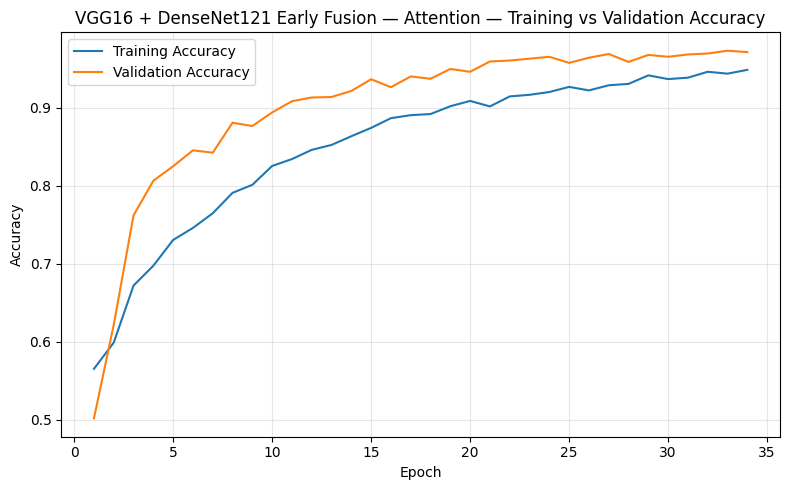

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_accuracy.png


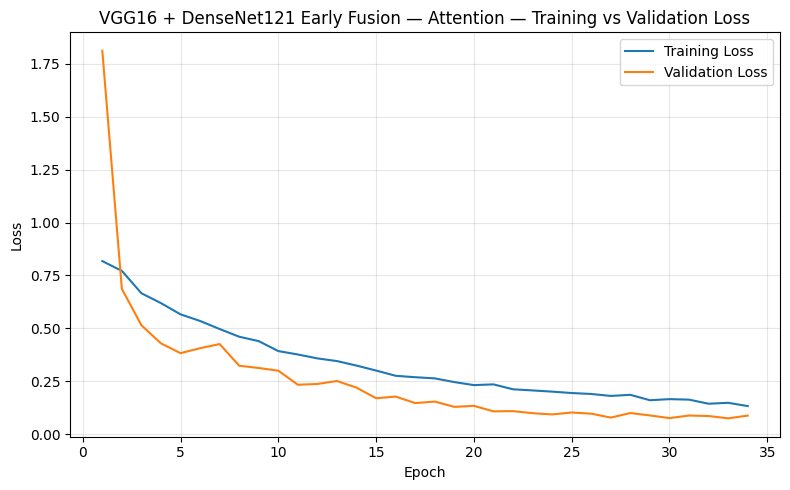

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_loss.png


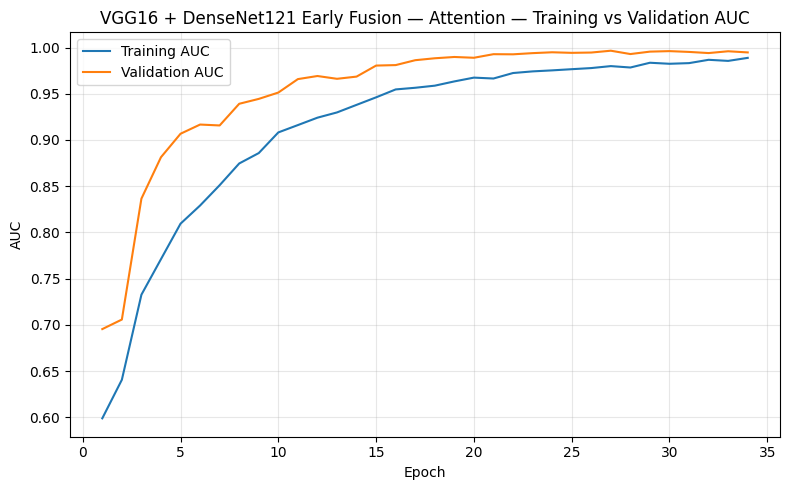

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_auc.png
209/209 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step

VGG16 + DenseNet121 Early Fusion — Attention
Accuracy: 0.9766187050359713
Precision: 0.9794933655006032
Recall: 0.973621103117506
F1 Score: 0.9765484064942874
ROC AUC: 0.9975875414776093

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9738    0.9796    0.9767       834
   Parkinson     0.9795    0.9736    0.9765       834

    accuracy                         0.9766      1668
   macro avg     0.9766    0.9766    0.9766      1668
weighted avg     0.9766    0.9766    0.9766      1668

ROC NPZ saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_roc_data.npz
NPZ keys: ['y_true', 'y_prob']
y_true shape: (1668,)
y_prob shape: (1668,)
y_true values: [0 1]
y_prob range: 2.8977513011341216e-06 to 0.99999964237

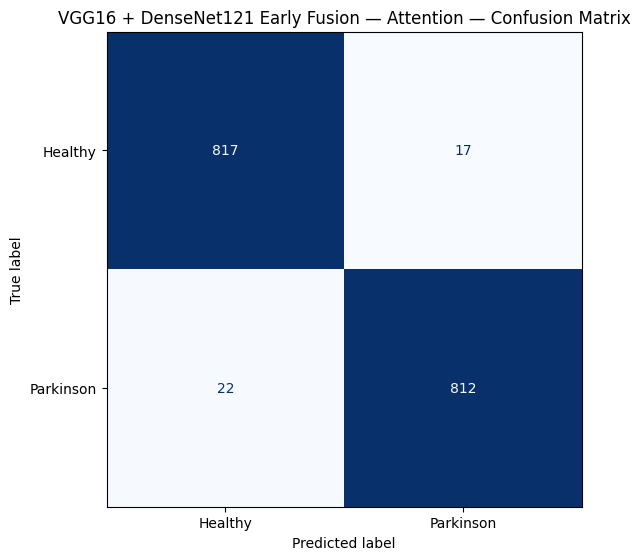

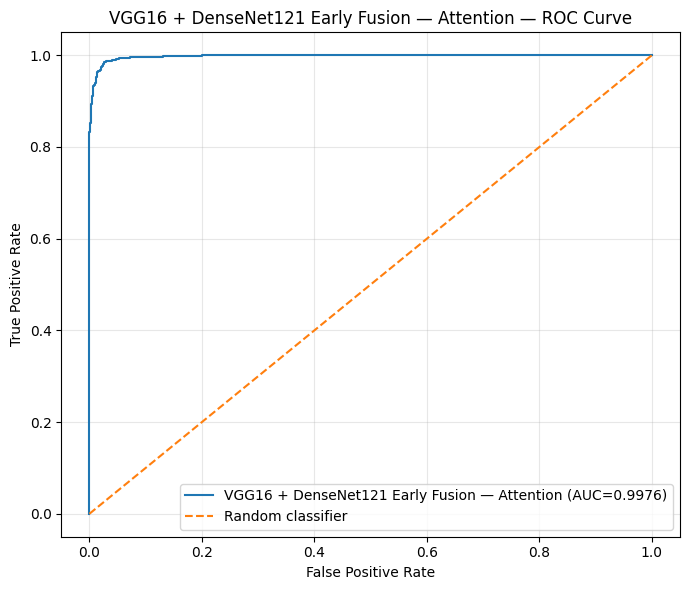

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_model_summary.txt
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_parameters.csv
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_metrics.csv
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_classification_report.txt
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_confusion_matrix.png
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_roc_curve.png
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_test_predictions.csv
Attention model released from mem

In [13]:
# ================================
# TRAIN MODEL B: ATTENTION FUSION
# ================================

model_name_attention = "VGG16 + DenseNet121 Early Fusion — Attention"
attention_prefix = "vgg16_densenet_attention_early_fusion"
attention_checkpoint_path = os.path.join(
    MODEL_DIR,
    "VGG16_DenseNet121_Early_Fusion_Attention_best.keras",
)

attention_model = build_vgg16_densenet_attention_model(base_trainable=True)
attention_model.summary()

callbacks_attention = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=attention_checkpoint_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    CSVLogger(
        filename=os.path.join(
            HISTORY_DIR,
            f"{attention_prefix}_training_log.csv",
        )
    ),
]

history_attention = attention_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_attention,
)

attention_final_path = os.path.join(
    MODEL_DIR,
    "VGG16_DenseNet121_Early_Fusion_Attention_final.keras",
)
attention_model.save(attention_final_path)
print("Final model saved:", attention_final_path)

history_attention_path = os.path.join(
    HISTORY_DIR,
    f"{attention_prefix}_history.json",
)
with open(history_attention_path, "w", encoding="utf-8") as file:
    json.dump(history_attention.history, file)
print("History saved:", history_attention_path)

plot_training_history(
    history_attention,
    model_name_attention,
    attention_prefix,
)

results_attention = evaluate_model(
    attention_model,
    test_gen,
    model_name_attention,
    attention_prefix,
)
results_attention["checkpoint_path"] = attention_checkpoint_path
results_attention["final_model_path"] = attention_final_path

# The best model will be loaded again after comparison.
del attention_model
del history_attention
gc.collect()
tf.keras.backend.clear_session()
print("Attention model released from memory.")

In [14]:
# ================================
# COMPARE MODELS AND SELECT THE BEST EARLY-FUSION MODEL
# ================================

fusion_comparison_df = pd.DataFrame(
    [
        {
            "Model": results_concat["model_name"],
            "Fusion Method": "Concatenation",
            "Backbones": "VGG16 + DenseNet121",
            "Accuracy": results_concat["accuracy"],
            "Precision": results_concat["precision"],
            "Recall": results_concat["recall"],
            "F1 Score": results_concat["f1_score"],
            "ROC AUC": results_concat["roc_auc"],
            "Total Parameters": results_concat["total_params"],
            "Trainable Parameters": results_concat["trainable_params"],
            "Non-Trainable Parameters": results_concat["non_trainable_params"],
        },
        {
            "Model": results_attention["model_name"],
            "Fusion Method": "Attention",
            "Backbones": "VGG16 + DenseNet121",
            "Accuracy": results_attention["accuracy"],
            "Precision": results_attention["precision"],
            "Recall": results_attention["recall"],
            "F1 Score": results_attention["f1_score"],
            "ROC AUC": results_attention["roc_auc"],
            "Total Parameters": results_attention["total_params"],
            "Trainable Parameters": results_attention["trainable_params"],
            "Non-Trainable Parameters": results_attention["non_trainable_params"],
        },
    ]
)

comparison_path = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_densenet_early_fusion_comparison.csv",
)
fusion_comparison_df.to_csv(comparison_path, index=False)
print("Comparison saved:", comparison_path)
print(fusion_comparison_df.to_string(index=False))

# Ranking order requested for the best model: ROC-AUC, then F1, then accuracy.
all_results = [results_concat, results_attention]
best_result = max(
    all_results,
    key=lambda result: (
        result["roc_auc"],
        result["f1_score"],
        result["accuracy"],
    ),
)

BEST_FUSION_MODEL_NAME = best_result["model_name"]
BEST_FUSION_MODEL_PATH = best_result["checkpoint_path"]
BEST_FUSION_PREFIX = best_result["file_prefix"]

print("\nBest early-fusion model:", BEST_FUSION_MODEL_NAME)
print("Best model path:", BEST_FUSION_MODEL_PATH)

# Save a standard alias so the combined ROC notebook can load one predictable file.
best_roc_alias = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_densenet_early_fusion_roc_data.npz",
)
np.savez(
    best_roc_alias,
    y_true=best_result["y_true"],
    y_prob=best_result["y_prob"],
)
print("Best-model ROC alias saved:", best_roc_alias)

best_summary_path = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_densenet_early_fusion_best_model_summary.txt",
)
with open(best_summary_path, "w", encoding="utf-8") as file:
    file.write(f"Best model: {BEST_FUSION_MODEL_NAME}\n")
    file.write(f"Checkpoint: {BEST_FUSION_MODEL_PATH}\n")
    file.write(f"Accuracy: {best_result['accuracy']:.8f}\n")
    file.write(f"Precision: {best_result['precision']:.8f}\n")
    file.write(f"Recall: {best_result['recall']:.8f}\n")
    file.write(f"F1 Score: {best_result['f1_score']:.8f}\n")
    file.write(f"ROC AUC: {best_result['roc_auc']:.8f}\n")
    file.write(f"Total Parameters: {best_result['total_params']}\n")
    file.write(f"Trainable Parameters: {best_result['trainable_params']}\n")
    file.write(
        f"Non-Trainable Parameters: {best_result['non_trainable_params']}\n"
    )
print("Saved:", best_summary_path)

best_parameters_alias = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_densenet_early_fusion_best_model_parameters.csv",
)
shutil.copyfile(best_result["parameter_path"], best_parameters_alias)
print("Saved:", best_parameters_alias)

Comparison saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_comparison.csv
                                           Model Fusion Method           Backbones  Accuracy  Precision   Recall  F1 Score  ROC AUC  Total Parameters  Trainable Parameters  Non-Trainable Parameters
VGG16 + DenseNet121 Early Fusion — Concatenation Concatenation VGG16 + DenseNet121  0.907674   0.875276 0.950839  0.911494 0.970231          22707073              22621633                     85440
    VGG16 + DenseNet121 Early Fusion — Attention     Attention VGG16 + DenseNet121  0.976619   0.979493 0.973621  0.976548 0.997588          22247299              22162883                     84416

Best early-fusion model: VGG16 + DenseNet121 Early Fusion — Attention
Best model path: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/models/VGG16_DenseNet121_Early_Fusion_Attention_best.keras
Best-model ROC alias saved: /content/drive/MyDrive/VGG16_DENSET_DATA_S

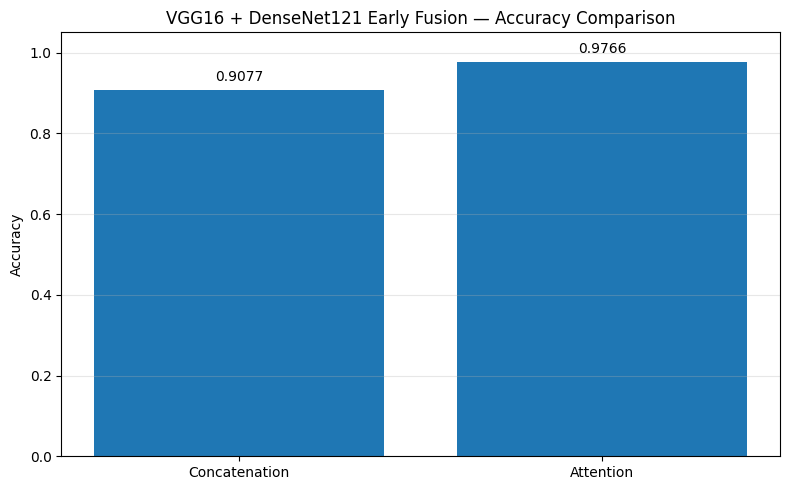

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_accuracy_comparison.png


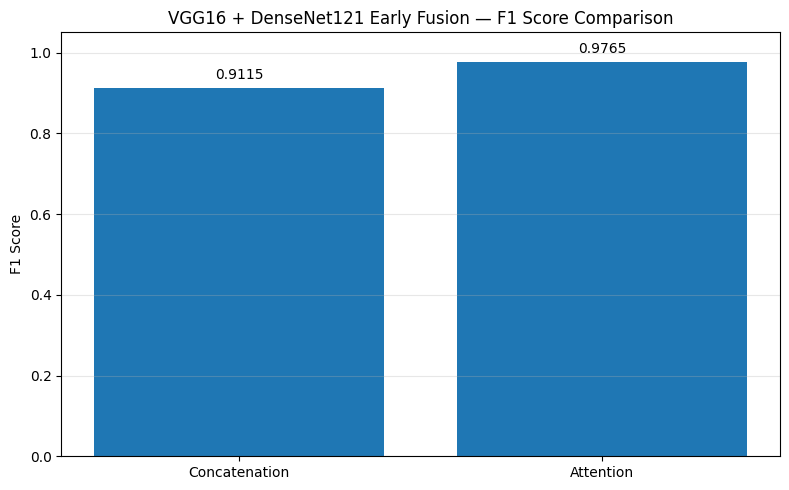

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_f1_comparison.png


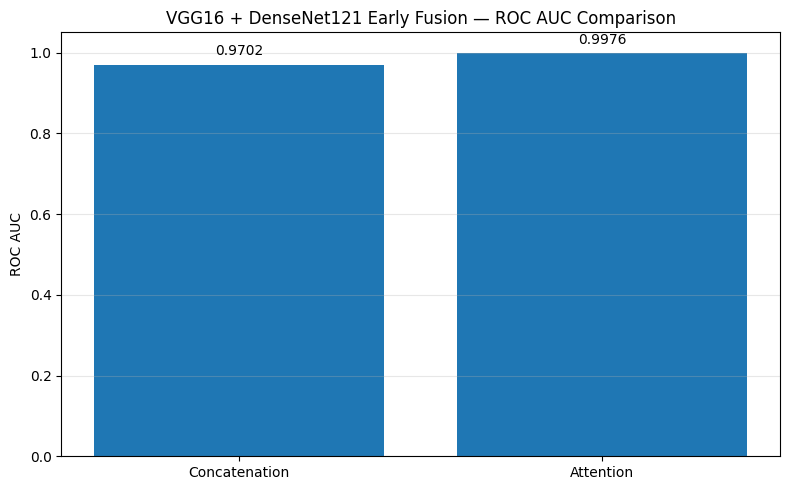

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_auc_comparison.png


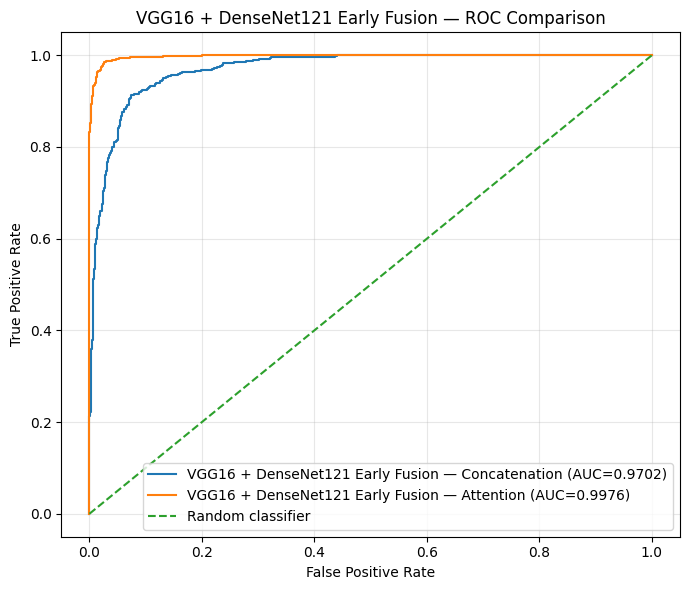

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_combined_roc_curve.png


In [15]:
# ================================
# COMPARISON GRAPHS + COMBINED ROC
# ================================

for metric, ylabel, filename in [
    ("Accuracy", "Accuracy", "vgg16_densenet_early_fusion_accuracy_comparison.png"),
    ("F1 Score", "F1 Score", "vgg16_densenet_early_fusion_f1_comparison.png"),
    ("ROC AUC", "ROC AUC", "vgg16_densenet_early_fusion_auc_comparison.png"),
]:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        fusion_comparison_df["Fusion Method"],
        fusion_comparison_df[metric],
    )
    plt.title(f"VGG16 + DenseNet121 Early Fusion — {ylabel} Comparison")
    plt.ylabel(ylabel)
    plt.ylim(0, 1.05)
    plt.grid(axis="y", alpha=0.3)

    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            min(value + 0.015, 1.03),
            f"{value:.4f}",
            ha="center",
            va="bottom",
        )

    save_path = os.path.join(ROOT_OUTPUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

# Combined ROC curve for both VGG16 + DenseNet121 early-fusion methods.
plt.figure(figsize=(7, 6))
for result in all_results:
    fpr, tpr, _ = roc_curve(result["y_true"], result["y_prob"])
    plt.plot(
        fpr,
        tpr,
        label=f"{result['model_name']} (AUC={result['roc_auc']:.4f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG16 + DenseNet121 Early Fusion — ROC Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
combined_roc_path = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_densenet_early_fusion_combined_roc_curve.png",
)
plt.savefig(combined_roc_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", combined_roc_path)

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import re
import cv2
import matplotlib.pyplot as plt

# ================================
# KERAS 3–SAFE BRANCH-WISE GRAD-CAM FOR THE BEST FUSION MODEL
# ================================

GRADCAM_FILE_PREFIX = "vgg16_densenet_early_fusion"

def load_fusion_model_safely(model_path):
    # Define custom objects needed for loading models, including new custom preprocessing layers.
    custom_objects = {
        "VGG16PreprocessingLayer": VGG16PreprocessingLayer,
        "DenseNetPreprocessingLayer": DenseNetPreprocessingLayer,
        # Include any other custom objects if needed (e.g., specific Lambda functions if not replaced)
    }
    try:
        return keras.models.load_model(
            model_path,
            compile=False,
            safe_mode=False,
            custom_objects=custom_objects,  # Pass custom objects here
        )
    except TypeError:
        # Compatibility fallback for TensorFlow versions without safe_mode.
        return keras.models.load_model(
            model_path,
            compile=False,
            custom_objects=custom_objects,  # Pass custom objects here as well
        )


def call_layer_inference(layer, inputs):
    try:
        return layer(inputs, training=False)
    except TypeError:
        return layer(inputs)


def resolve_conv_layer(backbone, candidates):
    for layer_name in candidates:
        try:
            layer = backbone.get_layer(layer_name)
            if len(layer.output.shape) == 4:
                return layer
        except (ValueError, AttributeError):
            continue

    conv_layers = [
        layer
        for layer in backbone.layers
        if isinstance(layer, layers.Conv2D) and len(layer.output.shape) == 4
    ]

    if not conv_layers:
        raise ValueError(
            f"No valid Conv2D layer was found inside {backbone.name}."
        )

    return conv_layers[-1]


def build_early_fusion_gradcam_context(model):
    if len(model.inputs) != 1:
        raise ValueError(
            f"This notebook model is expected to have one shared MRI input, "
            f"but {len(model.inputs)} inputs were found."
        )

    vgg_backbone = model.get_layer("vgg16_backbone")
    dense_backbone = model.get_layer("densenet121_backbone")

    vgg_conv_layer = resolve_conv_layer(
        vgg_backbone,
        ["block5_conv3", "block5_conv2", "block5_conv1"],
    )
    dense_conv_layer = resolve_conv_layer(
        dense_backbone,
        [
            "conv5_block16_2_conv",
            "conv5_block16_1_conv",
            "conv5_block15_2_conv",
        ],
    )

    # Each probe uses the nested backbone's own graph, avoiding Keras 3
    # disconnected-graph and Functional.call KeyErrors.
    vgg_probe = keras.Model(
        inputs=vgg_backbone.input,
        outputs=[vgg_conv_layer.output, vgg_backbone.output],
        name="vgg16_gradcam_probe",
    )
    dense_probe = keras.Model(
        inputs=dense_backbone.input,
        outputs=[dense_conv_layer.output, dense_backbone.output],
        name="densenet121_gradcam_probe",
    )

    if "early_fusion_concatenation" in [layer.name for layer in model.layers]:
        fusion_type = "Concatenation"
        fusion_layer = model.get_layer("early_fusion_concatenation")
    elif "early_fusion_attention" in [layer.name for layer in model.layers]:
        fusion_type = "Attention"
        fusion_layer = model.get_layer("early_fusion_attention")
    else:
        raise ValueError("A supported early-fusion layer was not found.")

    prediction_layer = model.get_layer("prediction")

    context = {
        "model": model,
        "vgg_backbone": vgg_backbone,
        "dense_backbone": dense_backbone,
        "vgg_conv_layer": vgg_conv_layer,
        "dense_conv_layer": dense_conv_layer,
        "vgg_probe": vgg_probe,
        "dense_probe": dense_probe,
        "fusion_type": fusion_type,
        "fusion_layer": fusion_layer,
        "prediction_layer": prediction_layer,
    }

    print("Loaded best model:", model.name)
    print("Fusion type:", fusion_type)
    print("Model input shape:", model.input_shape)
    print("VGG16 Grad-CAM layer:", vgg_conv_layer.name, vgg_conv_layer.output.shape)
    print(
        "DenseNet121 Grad-CAM layer:",
        dense_conv_layer.name, dense_conv_layer.output.shape,
    )

    return context


def forward_with_branch_feature_maps(context, image_batch):
    model = context["model"]

    vgg_input = call_layer_inference(
        model.get_layer("vgg16_preprocessing"),
        image_batch,
    )
    dense_input = call_layer_inference(
        model.get_layer("densenet_preprocessing"),
        image_batch,
    )

    vgg_conv, vgg_output = context["vgg_probe"](
        vgg_input,
        training=False,
    )
    dense_conv, dense_output = context["dense_probe"](
        dense_input,
        training=False,
    )

    vgg_vector = call_layer_inference(
        model.get_layer("vgg16_gap"),
        vgg_output,
    )
    dense_vector = call_layer_inference(
        model.get_layer("densenet_gap"),
        dense_output,
    )

    if context["fusion_type"] == "Concatenation":
        fused = call_layer_inference(
            context["fusion_layer"],
            [vgg_vector, dense_vector],
        )
    else:
        vgg_projected = call_layer_inference(
            model.get_layer("vgg16_projected"),
            vgg_vector,
        )
        dense_projected = call_layer_inference(
            model.get_layer("densenet_projected"),
            dense_vector,
        )
        attention_input = call_layer_inference(
            model.get_layer("attention_input"),
            [vgg_projected, dense_projected],
        )
        attention_weights = call_layer_inference(
            model.get_layer("branch_attention_weights"),
            attention_input,
        )
        weighted_vgg = call_layer_inference(
            model.get_layer("weighted_vgg16_features"),
            [vgg_projected, attention_weights],
        )
        weighted_dense = call_layer_inference(
            model.get_layer("weighted_densenet_features"),
            [dense_projected, attention_weights],
        )
        fused = call_layer_inference(
            context["fusion_layer"],
            [weighted_vgg, weighted_dense],
        )

    # Reuse every trained classifier-head layer after the fusion layer.
    fusion_index = model.layers.index(context["fusion_layer"])
    x = fused

    for layer in model.layers[fusion_index + 1 :]:
        if layer.name == "prediction":
            break
        x = call_layer_inference(layer, x)

    # Calculate the true pre-sigmoid logit from the trained final layer.
    prediction_layer = context["prediction_layer"]
    logits = tf.linalg.matmul(x, prediction_layer.kernel)
    if prediction_layer.use_bias:
        logits = tf.nn.bias_add(logits, prediction_layer.bias)
    probabilities = tf.nn.sigmoid(logits)

    return vgg_conv, dense_conv, logits, probabilities


def heatmap_from_gradient(feature_maps, gradients):
    # Determine the shape for a zero heatmap
    initial_heatmap_shape = feature_maps.shape[1:3]
    zero_heatmap_array = tf.zeros(initial_heatmap_shape, dtype=tf.float32).numpy().astype(np.float32)

    diagnostics = {
        "valid": True,
        "reason": "",
        "gradient_norm": 0.0,
        "raw_max": 0.0,
        "heatmap_max": 0.0,
        "nonzero_fraction": 0.0,
    }

    if gradients is None:
        diagnostics.update({
            "valid": False,
            "reason": "Gradients are None",
        })
        return zero_heatmap_array, diagnostics

    gradient_norm = float(tf.norm(gradients).numpy())
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    raw_heatmap = tf.reduce_sum(
        feature_maps[0] * pooled_gradients,
        axis=-1,
    )
    raw_heatmap = tf.nn.relu(raw_heatmap)
    raw_max = float(tf.reduce_max(raw_heatmap).numpy())

    diagnostics.update({
        "gradient_norm": gradient_norm,
        "raw_max": raw_max,
    })

    if not np.isfinite(gradient_norm) or not np.isfinite(raw_max):
        diagnostics.update({
            "valid": False,
            "reason": "Non-finite gradient or heatmap",
        })
        return zero_heatmap_array, diagnostics

    # If the gradient is zero, the heatmap should be zero.
    if gradient_norm <= 0.0:
        diagnostics.update({
            "valid": False,
            "reason": "Zero gradient",
        })
        return zero_heatmap_array, diagnostics

    # If raw_max is effectively zero, the heatmap will be all zeros after normalization.
    # We still compute it but mark it as invalid for interpretation.
    if raw_max <= 1e-12: # Use a very small epsilon to catch near-zero cases
        diagnostics.update({
            "valid": False,
            "reason": "Effectively zero positive activation (raw_max <= 1e-12)",
        })
        # To avoid division by zero if raw_max is literally 0.0, use a small epsilon for division
        effective_raw_max = max(raw_max, 1e-12)
        heatmap = (raw_heatmap / effective_raw_max).numpy().astype(np.float32)
    else:
        heatmap = (raw_heatmap / raw_max).numpy().astype(np.float32)

    nonzero_fraction = float(np.mean(heatmap > 1e-8))

    diagnostics.update({
        "heatmap_max": float(np.max(heatmap)),
        "nonzero_fraction": nonzero_fraction,
    })

    return heatmap, diagnostics


def make_vgg16_densenet_earlyfusion_gradcam(
    context,
    image_batch,
    target_class,
):
    image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

    if image_tensor.shape.rank == 3:
        image_tensor = tf.expand_dims(image_tensor, axis=0)

    with tf.GradientTape(persistent=True) as tape:
        vgg_maps, dense_maps, logits, probabilities = (
            forward_with_branch_feature_maps(context, image_tensor)
        )

        tape.watch(vgg_maps)
        tape.watch(dense_maps)

        logit = logits[0, 0]
        target_score = logit if int(target_class) == 1 else -logit

    vgg_gradients = tape.gradient(target_score, vgg_maps)
    dense_gradients = tape.gradient(target_score, dense_maps)
    del tape

    vgg_heatmap, vgg_diagnostics = heatmap_from_gradient(
        vgg_maps,
        vgg_gradients,
    )
    dense_heatmap, dense_diagnostics = heatmap_from_gradient(
        dense_maps,
        dense_gradients,
    )

    probability = float(probabilities[0, 0].numpy())
    predicted_class = int(probability >= 0.5)

    diagnostics = {
        "probability": probability,
        "predicted_class": predicted_class,
        "target_class": int(target_class),
        "target_logit": float(target_score.numpy()),
        "vgg": vgg_diagnostics,
        "dense": dense_diagnostics,
    }

    return vgg_heatmap, dense_heatmap, diagnostics


def resize_heatmap_and_overlay(original_rgb, heatmap, alpha=0.40):
    original = np.asarray(original_rgb, dtype=np.float32)
    if original.max() > 1.0:
        original = original / 255.0
    original = np.clip(original, 0.0, 1.0)

    resized_heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        (original.shape[0], original.shape[1]),
        method="bilinear",
    ).numpy().squeeze()
    resized_heatmap = np.clip(resized_heatmap, 0.0, 1.0)

    # Matplotlib returns RGBA. Keep only RGB to prevent shape errors.
    colored_heatmap = plt.colormaps["jet"](resized_heatmap)[..., :3]
    overlay = np.clip(
        (1.0 - alpha) * original + alpha * colored_heatmap,
        0.0,
        1.0,
    )

    if original.shape[-1] != 3 or colored_heatmap.shape[-1] != 3:
        raise ValueError(
            f"RGB shape validation failed: image={original.shape}, "
            f"heatmap={colored_heatmap.shape}"
        )

    return resized_heatmap, overlay


def representative_image_score(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return -np.inf

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    foreground = image > 0.06
    foreground_ratio = float(foreground.mean())

    if foreground_ratio < 0.12 or foreground_ratio > 0.90:
        return -np.inf

    contrast = float(image[foreground].std()) if foreground.any() else 0.0
    central = foreground[
        int(0.08 * IMG_SIZE) : int(0.82 * IMG_SIZE),
        int(0.10 * IMG_SIZE) : int(0.90 * IMG_SIZE),
    ]
    central_ratio = float(central.mean())

    total_foreground = max(float(foreground.sum()), 1.0)
    bottom_fraction = float(
        foreground[int(0.78 * IMG_SIZE) :, :].sum() / total_foreground
    )

    if contrast < 0.04 or central_ratio < 0.10:
        return -np.inf

    return (
        2.0 * central_ratio
        + foreground_ratio
        + contrast
        - 1.5 * bottom_fraction
    )


def extract_patient_id(image_path):
    match = re.search(r"PPMI[_-](\d+)", os.path.basename(image_path), re.IGNORECASE)
    if match:
        return match.group(1)
    return os.path.basename(image_path).split("_slice")[0]


Loaded best model: VGG16_DenseNet121_Early_Fusion_Attention
Fusion type: Attention
Model input shape: (None, 224, 224, 3)
VGG16 Grad-CAM layer: block5_conv3 (None, 14, 14, 512)
DenseNet121 Grad-CAM layer: conv5_block16_2_conv (None, 7, 7, 32)
Skipping all-invalid Grad-CAM: /content/drive/MyDrive/VGG16_DENSENET_/Parkinson_dataset/healthy_dataset/control_png/PPMI_140451_MR_SAG_3D_MPRAGE__br_raw_20220429002636230_97_S1129097_I1575216.png
VGG16 diagnostics: {'valid': False, 'reason': 'Zero gradient', 'gradient_norm': 0.0, 'raw_max': 1.1977077502217228e-34, 'heatmap_max': 0.0, 'nonzero_fraction': 0.0}
DenseNet121 diagnostics: {'valid': False, 'reason': 'Effectively zero positive activation (raw_max <= 1e-12)', 'gradient_norm': 5.442470073699951, 'raw_max': 0.0, 'heatmap_max': 0.0, 'nonzero_fraction': 0.0}


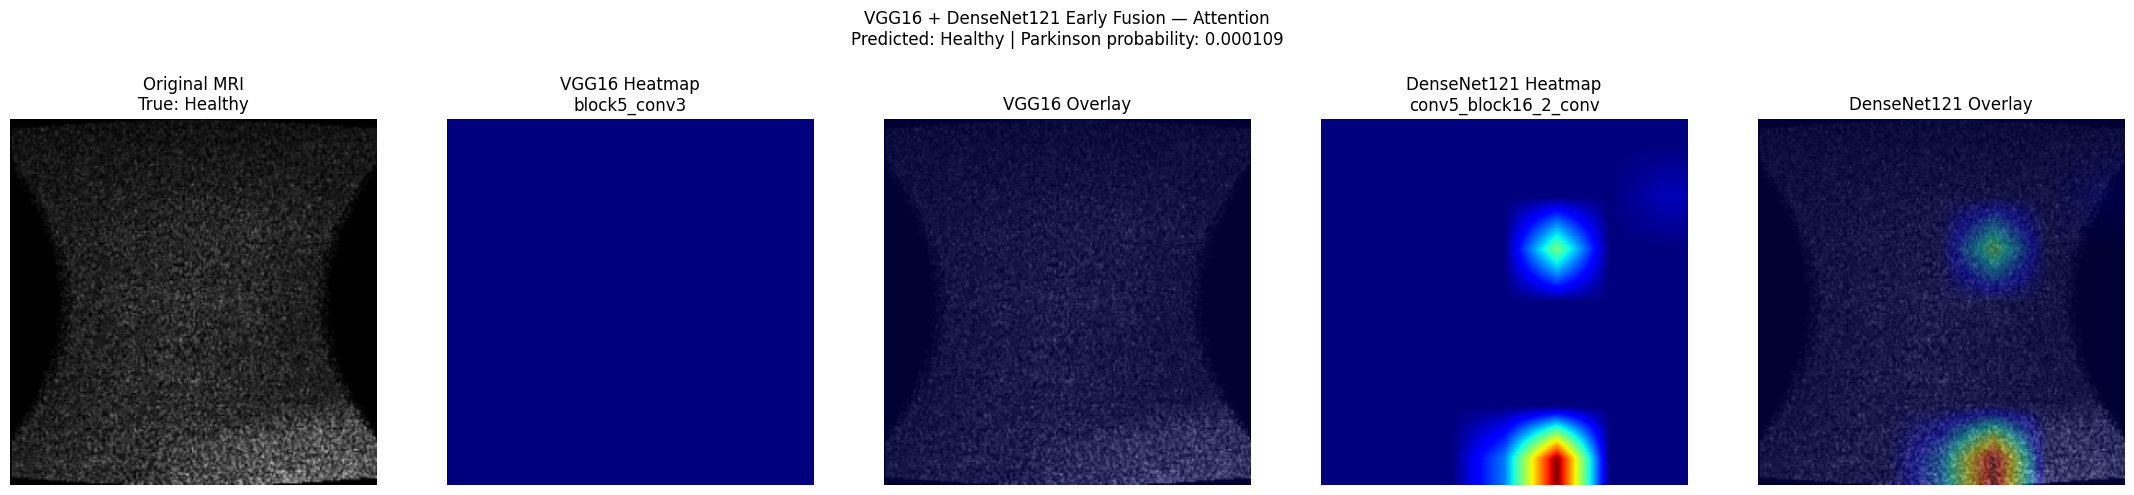

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_gradcam_healthy_1.png
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_gradcam_data_healthy_1.npz
VGG16 diagnostics: {'valid': False, 'reason': 'Zero gradient', 'gradient_norm': 0.0, 'raw_max': 2.3694588646581478e-21, 'heatmap_max': 0.0, 'nonzero_fraction': 0.0}
DenseNet121 diagnostics: {'valid': True, 'reason': '', 'gradient_norm': 3.966339349746704, 'raw_max': 0.0034655570052564144, 'heatmap_max': 1.0, 'nonzero_fraction': 0.10204081632653061}
Skipping sample because manual and direct predictions differ: 0.002539999783039093
Skipping sample because manual and direct predictions differ: 0.001036887988448143
Skipping sample because manual and direct predictions differ: 0.00018669292330741882
Skipping sample because manual and direct predictions differ: 0.00010804366320371628
Skipping sample because manual and direct predictions dif

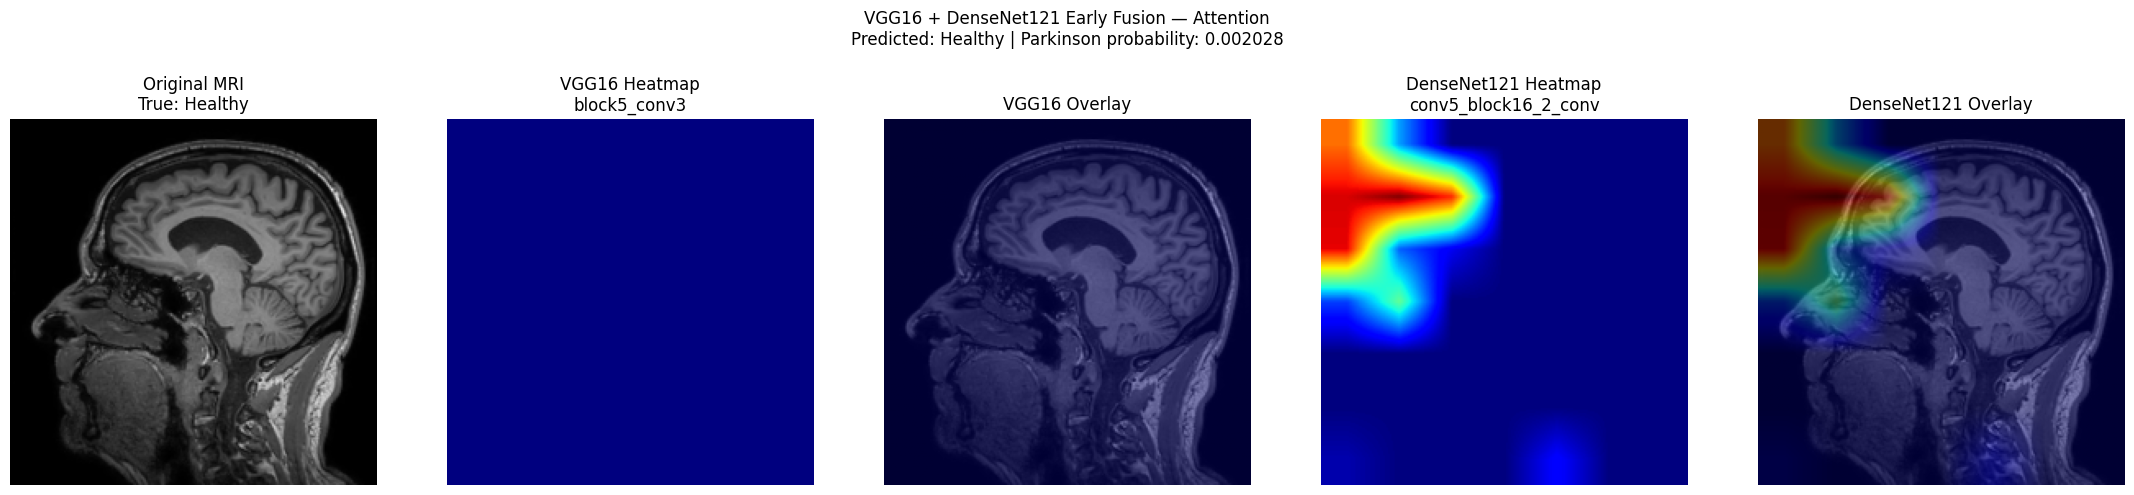

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_gradcam_healthy_2.png
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_gradcam_data_healthy_2.npz
VGG16 diagnostics: {'valid': False, 'reason': 'Zero gradient', 'gradient_norm': 0.0, 'raw_max': 1.0005082413779663e-34, 'heatmap_max': 0.0, 'nonzero_fraction': 0.0}
DenseNet121 diagnostics: {'valid': True, 'reason': '', 'gradient_norm': 4.026992321014404, 'raw_max': 0.008999165147542953, 'heatmap_max': 1.0, 'nonzero_fraction': 0.24489795918367346}
Skipping sample because manual and direct predictions differ: 0.0005108118057250977


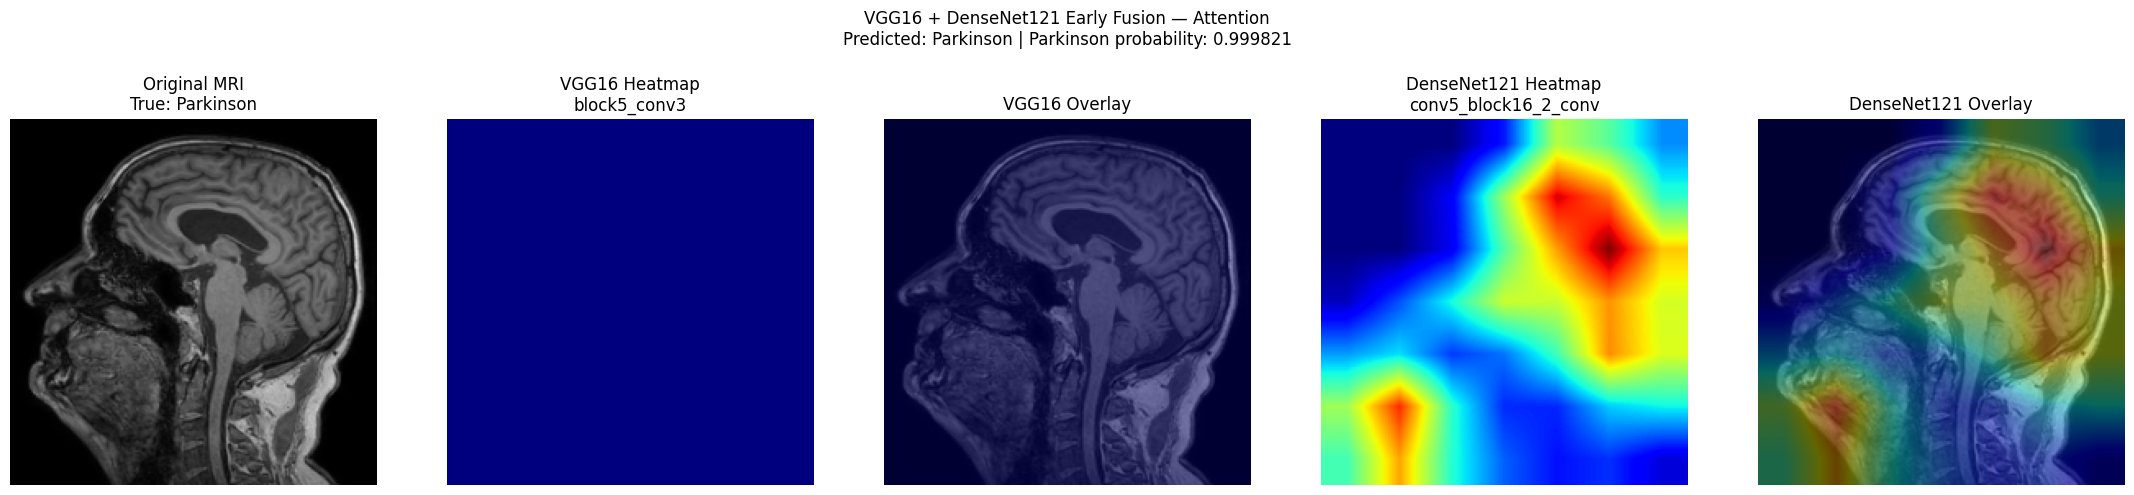

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_gradcam_parkinson_1.png
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_gradcam_data_parkinson_1.npz
VGG16 diagnostics: {'valid': False, 'reason': 'Zero gradient', 'gradient_norm': 0.0, 'raw_max': 2.4167061826952335e-34, 'heatmap_max': 0.0, 'nonzero_fraction': 0.0}
DenseNet121 diagnostics: {'valid': True, 'reason': '', 'gradient_norm': 4.424483776092529, 'raw_max': 0.05701695755124092, 'heatmap_max': 1.0, 'nonzero_fraction': 0.8571428571428571}
Skipping sample because manual and direct predictions differ: 0.0002471804618835449
Skipping sample because manual and direct predictions differ: 0.0014675259590148926
Skipping sample because manual and direct predictions differ: 0.009513556957244873
Skipping sample because manual and direct predictions differ: 0.00014472007751464844
Skipping sample because manual and direct predictions di

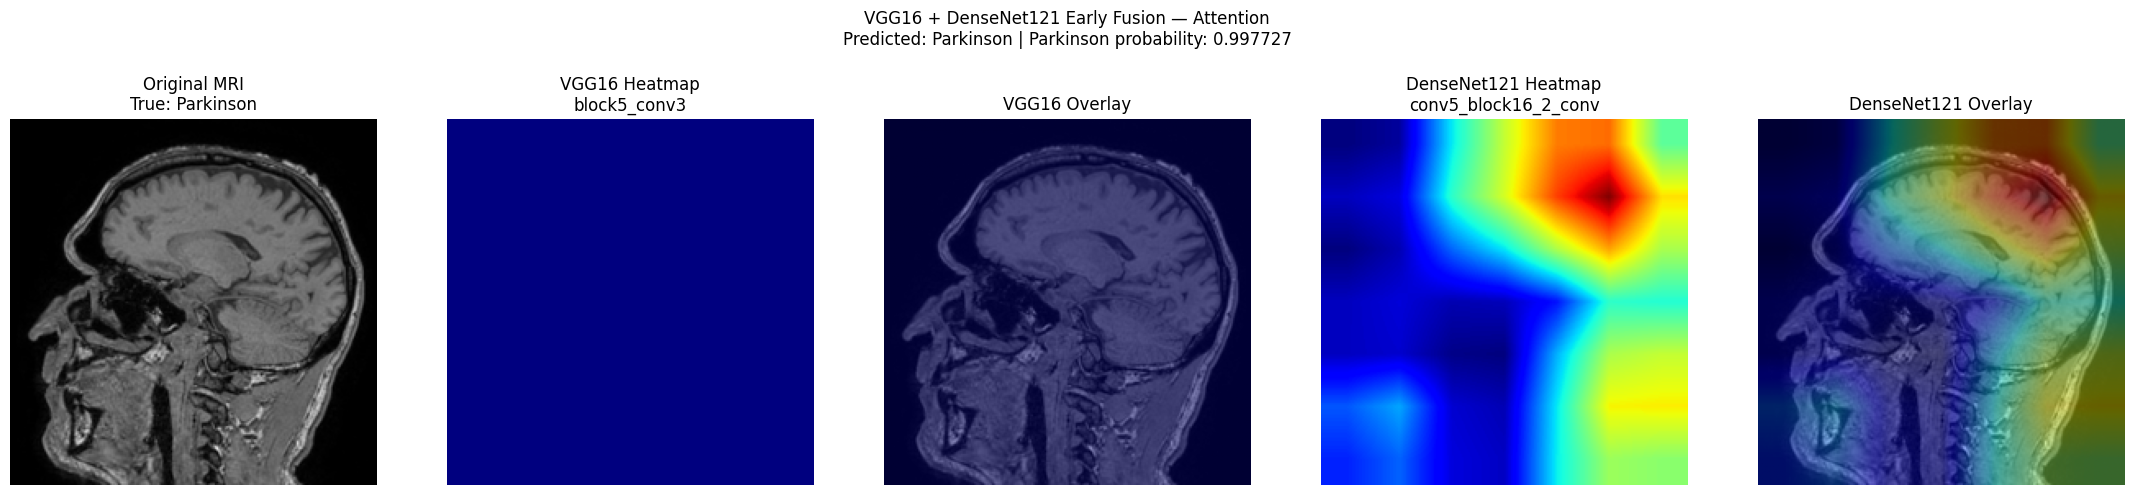

Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_gradcam_parkinson_2.png
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_gradcam_data_parkinson_2.npz
VGG16 diagnostics: {'valid': False, 'reason': 'Zero gradient', 'gradient_norm': 0.0, 'raw_max': 9.538723397190152e-35, 'heatmap_max': 0.0, 'nonzero_fraction': 0.0}
DenseNet121 diagnostics: {'valid': True, 'reason': '', 'gradient_norm': 3.5888686180114746, 'raw_max': 0.11030465364456177, 'heatmap_max': 1.0, 'nonzero_fraction': 0.9387755102040817}
Saved: /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_gradcam_results.csv
class_name  sample_number                                                                                                                                                                    image_path patient_id predicted_class  parkinson_probability  vgg16_layer

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import re
import cv2
import matplotlib.pyplot as plt

# ================================
# GENERATE FOUR VALID BRANCH-WISE GRAD-CAM FIGURES
# ================================

best_fusion_model = load_fusion_model_safely(BEST_FUSION_MODEL_PATH)
gradcam_context = build_early_fusion_gradcam_context(best_fusion_model)

# Use the already evaluated best-model predictions, which are aligned with
# the non-shuffled test generator.
test_paths = list(getattr(test_gen, "filepaths", []))
test_labels = np.asarray(test_gen.classes).astype(np.int32)
best_probabilities = np.asarray(best_result["y_prob"]).reshape(-1)

if not (
    len(test_paths) == len(test_labels) == len(best_probabilities)
):
    raise ValueError(
        "Grad-CAM input alignment failed: filepaths, labels, and probabilities "
        "do not have equal lengths."
    )

candidate_df = pd.DataFrame(
    {
        "image_path": test_paths,
        "true_label": test_labels,
        "probability": best_probabilities,
    }
)
candidate_df["predicted_label"] = (
    candidate_df["probability"] >= 0.5
).astype(np.int32)
candidate_df["correct"] = (
    candidate_df["true_label"] == candidate_df["predicted_label"]
)
candidate_df["patient_id"] = candidate_df["image_path"].map(extract_patient_id)
candidate_df["representative_score"] = candidate_df["image_path"].map(
    representative_image_score
)

selected_records = []
used_patient_ids = set()

for target_class, class_name in [(0, "Healthy"), (1, "Parkinson")]:
    class_candidates = candidate_df[
        (candidate_df["true_label"] == target_class)
        & (candidate_df["correct"])
        & np.isfinite(candidate_df["representative_score"])
    ].sort_values("representative_score", ascending=False)

    class_count = 0

    for _, row in class_candidates.head(100).iterrows():
        if row["patient_id"] in used_patient_ids:
            continue

        try:
            display_image = keras.utils.load_img(
                row["image_path"],
                target_size=(IMG_SIZE, IMG_SIZE),
                color_mode="rgb",
            )
            display_array = keras.utils.img_to_array(display_image).astype(np.float32)
            image_batch = np.expand_dims(display_array, axis=0)

            vgg_heatmap, dense_heatmap, diagnostics = (
                make_vgg16_densenet_earlyfusion_gradcam(
                    gradcam_context,
                    image_batch,
                    target_class=target_class,
                )
            )

            # Proceed if at least one heatmap is valid. Only skip if *both* are invalid.
            if not diagnostics["vgg"]["valid"] and not diagnostics["dense"]["valid"]:
                print("Skipping all-invalid Grad-CAM:", row["image_path"])
                print("VGG16 diagnostics:", diagnostics["vgg"])
                print("DenseNet121 diagnostics:", diagnostics["dense"])
                continue

            predicted_probability = diagnostics["probability"]
            predicted_class = diagnostics["predicted_class"]

            # Confirm that the manual graph-safe forward pass matches the model.
            direct_probability = float(
                best_fusion_model.predict(image_batch, verbose=0).reshape(-1)[0]
            )
            forward_difference = abs(direct_probability - predicted_probability)

            if forward_difference > 1e-4:
                print(
                    "Skipping sample because manual and direct predictions differ:",
                    forward_difference,
                )
                continue

            vgg_resized, vgg_overlay = resize_heatmap_and_overlay(
                display_array,
                vgg_heatmap,
                alpha=0.40,
            )
            dense_resized, dense_overlay = resize_heatmap_and_overlay(
                display_array,
                dense_heatmap,
                alpha=0.40,
            )

            sample_number = class_count + 1
            predicted_name = "Parkinson" if predicted_class == 1 else "Healthy"

            fig, axes = plt.subplots(1, 5, figsize=(22, 5))

            axes[0].imshow(display_array.astype(np.uint8))
            axes[0].set_title(f"Original MRI\nTrue: {class_name}")
            axes[0].axis("off")

            axes[1].imshow(vgg_resized, cmap="jet", vmin=0, vmax=1)
            axes[1].set_title(
                f"VGG16 Heatmap\n{gradcam_context['vgg_conv_layer'].name}"
            )
            axes[1].axis("off")

            axes[2].imshow(vgg_overlay)
            axes[2].set_title("VGG16 Overlay")
            axes[2].axis("off")

            axes[3].imshow(dense_resized, cmap="jet", vmin=0, vmax=1)
            axes[3].set_title(
                f"DenseNet121 Heatmap\n"
                f"{gradcam_context['dense_conv_layer'].name}"
            )
            axes[3].axis("off")

            axes[4].imshow(dense_overlay)
            axes[4].set_title("DenseNet121 Overlay")
            axes[4].axis("off")

            fig.suptitle(
                f"{BEST_FUSION_MODEL_NAME}\n"
                f"Predicted: {predicted_name} | "
                f"Parkinson probability: {predicted_probability:.6f}",
                fontsize=12,
            )
            fig.tight_layout(rect=[0, 0, 1, 0.90])

            figure_path = os.path.join(
                ROOT_OUTPUT_DIR,
                f"{GRADCAM_FILE_PREFIX}_gradcam_"
                f"{class_name.lower()}_{sample_number}.png",
            )
            fig.savefig(figure_path, dpi=300, bbox_inches="tight")
            plt.show()

            data_path = os.path.join(
                ROOT_OUTPUT_DIR,
                f"vgg16_densenet_gradcam_data_"
                f"{class_name.lower()}_{sample_number}.npz",
            )
            np.savez(
                data_path,
                vgg16_heatmap=vgg_heatmap,
                densenet121_heatmap=dense_heatmap,
                true_label=np.int32(target_class),
                predicted_label=np.int32(predicted_class),
                parkinson_probability=np.float32(predicted_probability),
                image_path=np.array(row["image_path"]),
                patient_id=np.array(row["patient_id"]),
                vgg16_layer=np.array(
                    gradcam_context["vgg_conv_layer"].name
                ),
                densenet121_layer=np.array(
                    gradcam_context["dense_conv_layer"].name
                ),
                vgg16_gradient_norm=np.float32(
                    diagnostics["vgg"]["gradient_norm"]
                ),
                densenet121_gradient_norm=np.float32(
                    diagnostics["dense"]["gradient_norm"]
                ),
            )

            selected_records.append(
                {
                    "class_name": class_name,
                    "sample_number": sample_number,
                    "image_path": row["image_path"],
                    "patient_id": row["patient_id"],
                    "predicted_class": predicted_name,
                    "parkinson_probability": predicted_probability,
                    "vgg16_layer": gradcam_context["vgg_conv_layer"].name,
                    "densenet121_layer": gradcam_context["dense_conv_layer"].name,
                    "vgg16_gradient_norm": diagnostics["vgg"]["gradient_norm"],
                    "densenet121_gradient_norm": diagnostics["dense"]["gradient_norm"],
                    "vgg16_heatmap_max": diagnostics["vgg"]["heatmap_max"],
                    "densenet121_heatmap_max": diagnostics["dense"]["heatmap_max"],
                    "figure_path": figure_path,
                    "npz_path": data_path,
                }
            )

            used_patient_ids.add(row["patient_id"])
            class_count += 1

            print("Saved:", figure_path)
            print("Saved:", data_path)
            print("VGG16 diagnostics:", diagnostics["vgg"])
            print("DenseNet121 diagnostics:", diagnostics["dense"])

            if class_count == 2:
                break

        except Exception:
            print("Grad-CAM failed for:", row["image_path"])
            traceback.print_exc()
            continue

    if class_count < 2:
        print(
            f"Warning: only {class_count} valid {class_name} Grad-CAM examples "
            "were generated. Review the printed diagnostics."
        )

selected_gradcam_df = pd.DataFrame(selected_records)
gradcam_results_path = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_densenet_early_fusion_gradcam_results.csv",
)
selected_gradcam_df.to_csv(gradcam_results_path, index=False)
print("Saved:", gradcam_results_path)
print(selected_gradcam_df.to_string(index=False))

In [18]:
# ================================
# FINAL OUTPUT VERIFICATION
# ================================

expected_files = [
    "vgg16_densenet_concat_early_fusion_roc_data.npz",
    "vgg16_densenet_attention_early_fusion_roc_data.npz",
    "vgg16_densenet_early_fusion_roc_data.npz",
    "vgg16_densenet_early_fusion_combined_roc_curve.png",
    "vgg16_densenet_early_fusion_best_model_summary.txt",
    "vgg16_densenet_early_fusion_best_model_parameters.csv",
    "vgg16_densenet_early_fusion_gradcam_healthy_1.png",
    "vgg16_densenet_early_fusion_gradcam_healthy_2.png",
    "vgg16_densenet_early_fusion_gradcam_parkinson_1.png",
    "vgg16_densenet_early_fusion_gradcam_parkinson_2.png",
    "vgg16_densenet_gradcam_data_healthy_1.npz",
    "vgg16_densenet_gradcam_data_healthy_2.npz",
    "vgg16_densenet_gradcam_data_parkinson_1.npz",
    "vgg16_densenet_gradcam_data_parkinson_2.npz",
    "vgg16_densenet_early_fusion_gradcam_results.csv",
]

verification_rows = []
for filename in expected_files:
    full_path = os.path.join(ROOT_OUTPUT_DIR, filename)
    exists = os.path.exists(full_path)
    verification_rows.append(
        {
            "filename": filename,
            "full_path": full_path,
            "exists": exists,
            "size_bytes": os.path.getsize(full_path) if exists else 0,
        }
    )

verification_df = pd.DataFrame(verification_rows)
verification_path = os.path.join(
    ROOT_OUTPUT_DIR,
    "vgg16_densenet_early_fusion_output_verification.csv",
)
verification_df.to_csv(verification_path, index=False)

print(verification_df.to_string(index=False))
print("\nVerification CSV saved:", verification_path)
print("\nAll paper-ready outputs are in:")
print(ROOT_OUTPUT_DIR)

                                             filename                                                                                                                        full_path  exists  size_bytes
      vgg16_densenet_concat_early_fusion_roc_data.npz       /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_concat_early_fusion_roc_data.npz    True       13854
   vgg16_densenet_attention_early_fusion_roc_data.npz    /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_attention_early_fusion_roc_data.npz    True       13854
             vgg16_densenet_early_fusion_roc_data.npz              /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_roc_data.npz    True       13854
   vgg16_densenet_early_fusion_combined_roc_curve.png    /content/drive/MyDrive/VGG16_DENSET_DATA_SAVE_HERE__/Paper_Ready_Artifacts/vgg16_densenet_early_fusion_combined_roc_curve.png    Tr